# CSIS 3290 – 004 – Final Project - New Data Set 
- Student Name: Isaac David Rangel Blanco
- ID: 300410730

I am using a New Dataset of New York City Yellow taxi trips in February of 2026 

- Link reference: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## Problem

For this project i want to predict the **total_amount** of NYC Yellow taxi trips using operational trip features such as distance, duration, pickup/drop-off zones, and rate type. 

## Dataset description

The original dataset contains aprox 4 millions of trips but i going to use just a sample of 200k of these records, with features like `trip_distance`, `passenger_count`, `RatecodeID`, pickup and drop-off locations (`PULocationID`, `DOLocationID`), and fare components (`fare_amount`, `Extra`, `tpep_pickup_datetime` and `tpep_dropoff_datetime` , etc.). 

The files **"data_dictionary_trip_records_yellow.pdf"** and **"taxi_zone_lookup.csv"** were important for understanding the dataset and mapping LocationID values to service zones during data transformation.

# Loading the Necessary Libraries

In [1]:
# Basic libraries Pandas, Numpy
import numpy as np
import pandas as pd

In [2]:
# Libraries for plotting and EDA
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Libraries for predictive models
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor 

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.linear_model import SGDRegressor

# Reading the dataset

The original dataset is in .parquet format, which is a columnar storage file format commonly used for big data applications. 
For this project, i convert the dataset to .csv using pandas to simplify data handling in Python and to ensure compatibility with tools that may not support Parquet files. 

link reference:
https://stackoverflow.com/questions/51215166/convert-parquet-to-csv

In [4]:
# The format of the original data set is .parquet , we can convert it to .csv

df = pd.read_parquet("Dataset/yellow_tripdata_2026-02.parquet")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3399866 entries, 0 to 3399865
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
# Also i take a sample of the original data because this contains more than 3 millions of rows
# i select just 200k from the orignal dataset, more than enough data (>=10k)

df = df.sample(200000, random_state=42)

# Saving the sample from the original dataset in csv format

df.to_csv("Dataset/taxi_data_test.csv", index=False)

 The df.sample() implementation allows me to:
- Randomly selects rows from a DataFrame.
- Often is used to create a subset for testing, debugging, or sampling data.

link reference:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html

In [6]:
# Reading the new dataset that is a sample from the original dataset

df=pd.read_csv('Dataset/taxi_data_test.csv')

# Having a peek of the data

In [7]:
# checking the content of the data frame

df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-02-16 15:07:30,2026-02-16 15:40:06,1.0,17.47,1.0,N,246,138,1,65.30,5.00,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75
1,2,2026-02-20 07:37:00,2026-02-20 07:48:00,NaN,2.14,NaN,NaN,238,140,0,16.96,0.00,0.5,0.00,0.00,1.0,22.96,NaN,NaN,0.00
2,2,2026-02-15 16:15:23,2026-02-15 16:22:18,1.0,1.27,1.0,N,237,236,1,9.30,0.00,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75
3,2,2026-02-09 13:56:56,2026-02-09 14:06:53,2.0,1.41,1.0,N,43,239,1,10.70,0.00,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00
4,2,2026-02-11 20:53:51,2026-02-11 21:12:00,2.0,2.73,1.0,N,230,263,1,17.70,1.00,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75
5,2,2026-02-01 09:52:33,2026-02-01 09:56:55,2.0,0.99,1.0,N,237,161,1,7.90,0.00,0.5,2.53,0.00,1.0,15.18,2.5,0.0,0.75
6,1,2026-02-07 09:20:01,2026-02-07 09:28:46,1.0,2.30,1.0,N,141,107,1,12.10,3.25,0.5,2.53,0.00,1.0,19.38,2.5,0.0,0.75
7,1,2026-02-16 19:02:28,2026-02-16 19:22:51,1.0,7.60,1.0,N,237,127,1,31.70,2.50,0.5,0.00,0.00,1.0,35.70,2.5,0.0,0.00
8,1,2026-02-12 19:35:12,2026-02-12 20:29:12,1.0,7.80,99.0,N,164,225,1,32.50,0.00,0.5,0.00,7.46,0.0,40.46,0.0,0.0,0.00
9,2,2026-02-08 17:40:39,2026-02-08 17:53:23,NaN,1.60,NaN,NaN,137,90,0,32.20,0.00,0.5,0.00,0.00,1.0,38.95,NaN,NaN,0.75


In [8]:
# Checking the data types, number of columns and rows
# Also the Null values in each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               200000 non-null  int64  
 1   tpep_pickup_datetime   200000 non-null  object 
 2   tpep_dropoff_datetime  200000 non-null  object 
 3   passenger_count        140156 non-null  float64
 4   trip_distance          200000 non-null  float64
 5   RatecodeID             140156 non-null  float64
 6   store_and_fwd_flag     140156 non-null  object 
 7   PULocationID           200000 non-null  int64  
 8   DOLocationID           200000 non-null  int64  
 9   payment_type           200000 non-null  int64  
 10  fare_amount            200000 non-null  float64
 11  extra                  200000 non-null  float64
 12  mta_tax                200000 non-null  float64
 13  tip_amount             200000 non-null  float64
 14  tolls_amount           200000 non-nu

# Cleaning the data
- The dataframe can be cleaned by changing label names, dropping and filling some data.
  
- Additionally, some features, such as **tpep_pickup_datetime** and **tpep_dropoff_datetime**, can be transformed into a more understandable format. For example, these two columns can be combined into a single feature that represents the total duration of the trip. Since all the data corresponds to January 2026, it is also possible to extract only the day and hour from the datetime values.
  
- Some columns in the dataset contain ID values; however, these do not correspond to unique user identifiers but instead represent categorical information, such as service providers (VendorID) and fare types (RatecodeID). Therefore, these variables are treated as categorical features and appropriately encoded before being used in the machine learning models:

- **VendorID:** A code indicating the TPEP provider of the record.
1 = Creative Mobile Technologies, LLC
2 = Curb Mobility, LLC
6 = Myle Technologies Inc
7 = Helix

- **RatecodeID:** The final rate code in effect at the end of the trip. 1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown

- **payment_type:** A numeric code signifying how the passenger paid for the trip.
0 = Flex Fare trip
1 = Credit card
2 = Cash
3 = No charge
4 = Dispute
5 = Unknown
6 = Voided trip

- **store_and_fwd_flag:** This flag indicates whether the trip record was held in vehicle memory before
sending to the vendor, aka “store and forward,” because the vehicle did not
have a connection to the server.
Y = store and forward trip
N = not a store and forward trip
 
- **PULocationID:** Pick Up - TLC Taxi Zone in which the taximeter was engaged.
 
- **DOLocationID:** Drop Off - TLC Taxi Zone in which the taximeter was disengaged.

Due to the high cardinality of the pickup and dropoff location identifiers, that are 265 different locations, these variables can be removed to simplify the model and avoid overfitting. Or as better option to avoid losing data, we can change this IDs to his respective service_zone(for this is necessary to check an extra dataset that contains this information)

Note: Previus data was obtained from the Data Dictionary provided from the link reference

In [9]:
# Creating a copy from the dataset 
df1 = df.copy()

## Changing Labels Names

In [10]:
# first removing any white space, and formatting to capital letter
# i prefer to keep the underscores for this dataset

df1.columns = df1.columns.str.title().str.replace(" ","")
df1.head()

,Vendorid,Tpep_Pickup_Datetime,Tpep_Dropoff_Datetime,Passenger_Count,Trip_Distance,Ratecodeid,Store_And_Fwd_Flag,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee
0,2,2026-02-16 15:07:30,2026-02-16 15:40:06,1.0,17.47,1.0,N,246,138,1,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75
1,2,2026-02-20 07:37:00,2026-02-20 07:48:00,NaN,2.14,NaN,NaN,238,140,0,16.96,0.0,0.5,0.00,0.00,1.0,22.96,NaN,NaN,0.00
2,2,2026-02-15 16:15:23,2026-02-15 16:22:18,1.0,1.27,1.0,N,237,236,1,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75
3,2,2026-02-09 13:56:56,2026-02-09 14:06:53,2.0,1.41,1.0,N,43,239,1,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00
4,2,2026-02-11 20:53:51,2026-02-11 21:12:00,2.0,2.73,1.0,N,230,263,1,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75


## Formatting DateTime columns

In [11]:
# modifiying datetime columns  	
# getting just the time from the tpep_pickup_datetime and tpep_dropoff_datetime columns

df1['PU_Time'] = df1['Tpep_Pickup_Datetime'].apply(lambda x: x.split()[1])  
df1['DO_Time'] = df1['Tpep_Dropoff_Datetime'].apply(lambda x: x.split()[1]) 


In [12]:
# changing the format from 21:18:42 to just minutes

df1['PU_Time'] = df1['PU_Time'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]) + int(x.split(':')[2])/60)
df1['DO_Time'] = df1['DO_Time'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]) + int(x.split(':')[2])/60)

# Creating duration column to simplify this data

df1['Trip_Duration'] = df1.apply(lambda row: row['DO_Time'] - row['PU_Time']
                                   if row['DO_Time'] >= row['PU_Time']
                                   else row['DO_Time'] - row['PU_Time'] + 24*60,axis=1)

# Dropping columns that were formated 

df1 = df1.drop(columns=['Tpep_Pickup_Datetime','Tpep_Dropoff_Datetime','PU_Time','DO_Time'])

In [13]:
df1.head()

,Vendorid,Passenger_Count,Trip_Distance,Ratecodeid,Store_And_Fwd_Flag,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
0,2,1.0,17.47,1.0,N,246,138,1,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75,32.600000
1,2,NaN,2.14,NaN,NaN,238,140,0,16.96,0.0,0.5,0.00,0.00,1.0,22.96,NaN,NaN,0.00,11.000000
2,2,1.0,1.27,1.0,N,237,236,1,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75,6.916667
3,2,2.0,1.41,1.0,N,43,239,1,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00,9.950000
4,2,2.0,2.73,1.0,N,230,263,1,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75,18.150000


## Columns with IDs 

In [14]:
# Changing the columns IDs with the respectivy categorical data

df1['Vendor']= df1['Vendorid'].replace({1: "Creative",2: "Curb",6: "Myle",7: "Helix"})

df1['Rate_Type'] = df1['Ratecodeid'].replace({1: "Standard rate",2: "JFK",3: "Newark",4: "Nassau",5: "Negotiated",6: "Group",99: pd.NA})

df1['Payment_Type'] = df1['Payment_Type'].replace({0: "Flex Fare",1: "Credit card",2: "Cash",3: "No charge",4: "Dispute",5: pd.NA,6: "Voided trip"})

df1['Stored_Flag'] = df1['Store_And_Fwd_Flag']


# Reducing the name size of the column 'Store_And_Fwd_Flag' by saving it in a new column

df1['Stored_Flag'] = df1['Store_And_Fwd_Flag']

# Then drop the original column
df1 = df1.drop(columns=['Store_And_Fwd_Flag','Vendorid','Ratecodeid'])

df1.head()

,Passenger_Count,Trip_Distance,Pulocationid,Dolocationid,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag
0,1.0,17.47,246,138,Credit card,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75,32.600000,Curb,Standard rate,N
1,NaN,2.14,238,140,Flex Fare,16.96,0.0,0.5,0.00,0.00,1.0,22.96,NaN,NaN,0.00,11.000000,Curb,NaN,NaN
2,1.0,1.27,237,236,Credit card,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75,6.916667,Curb,Standard rate,N
3,2.0,1.41,43,239,Credit card,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00,9.950000,Curb,Standard rate,N
4,2.0,2.73,230,263,Credit card,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75,18.150000,Curb,Standard rate,N


## PU(Pick Up) and DO(Drop Off) location columns

In [15]:
# Using an additional "Taxi Zones LookUp" Dataset and implementing some feature engineer techniques to modify these columns

# This data set contains the service zone for all the 265 locationIDs, so we first check the content 
taxi_zones = pd.read_csv('Dataset/taxi_zone_lookup.csv')
taxi_zones.head(10)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
5,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
6,7,Queens,Astoria,Boro Zone
7,8,Queens,Astoria Park,Boro Zone
8,9,Queens,Auburndale,Boro Zone
9,10,Queens,Baisley Park,Boro Zone


In [16]:
# Info of this additional data set
taxi_zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       264 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [17]:
# Cheking value count for the columns
# 4 categories for service zone, we can use this instead of the 265 locationIDs
taxi_zones.service_zone.value_counts()

service_zone
Boro Zone      205
Yellow Zone     55
Airports         2
EWR              1
Name: count, dtype: int64

In [18]:
# Value counts for the other 2 columns,
# These have to many categories, so is better using the Service Zones categories
taxi_zones.Zone.value_counts()

Zone
Governor's Island/Ellis Island/Liberty Island    3
Corona                                           2
Newark Airport                                   1
Ocean Hill                                       1
Parkchester                                      1
                                                ..
Fordham South                                    1
Forest Hills                                     1
Forest Park/Highland Park                        1
Fort Greene                                      1
Outside of NYC                                   1
Name: count, Length: 261, dtype: int64

In [19]:
taxi_zones.Borough.value_counts()

Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Unknown           1
Name: count, dtype: int64

 Mapping with dict + .map() allows me to:
 - create a dictionary from the additonal Dataframe by mapping each LocationID to a service zone.
 - Then use .map() to assign pickup and drop-off zones in original DataFrame.

Link reference:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html

In [20]:
# Creating a dictionary from the taxi_zones dataset to obtain the respective service_zone for each locationID for PU or DO

location_to_service = dict(zip(taxi_zones["LocationID"], taxi_zones["service_zone"]))

In [21]:
# Mapping PickUp and DropOff locationID, also creating new column with the service zone
df1["PU_zone"] = df1["Pulocationid"].map(location_to_service)

df1["DO_zone"] = df1["Dolocationid"].map(location_to_service)

# Dropping "PULocationID" and "DOLocationID", since we have new columns that refers to this features
df1 = df1.drop(columns=["Pulocationid", "Dolocationid"])

# Now instead of having IDs that refer to categorical data, we have the respective categorical data (4 categories)

df1.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
0,1.0,17.47,Credit card,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75,32.600000,Curb,Standard rate,N,Yellow Zone,Airports
1,NaN,2.14,Flex Fare,16.96,0.0,0.5,0.00,0.00,1.0,22.96,NaN,NaN,0.00,11.000000,Curb,NaN,NaN,Yellow Zone,Yellow Zone
2,1.0,1.27,Credit card,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75,6.916667,Curb,Standard rate,N,Yellow Zone,Yellow Zone
3,2.0,1.41,Credit card,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00,9.950000,Curb,Standard rate,N,Yellow Zone,Yellow Zone
4,2.0,2.73,Credit card,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75,18.150000,Curb,Standard rate,N,Yellow Zone,Yellow Zone


In [22]:
# checking the value count for the new columns
df1.PU_zone.value_counts()

PU_zone
Yellow Zone    163725
Boro Zone       24101
Airports        11846
EWR                20
Name: count, dtype: int64

In [23]:
# For PU and DU now is jsut 4 categories
df1.DO_zone.value_counts()

DO_zone
Yellow Zone    160801
Boro Zone       34869
Airports         2912
EWR               332
Name: count, dtype: int64

In [24]:
df1.Stored_Flag.value_counts()

Stored_Flag
N    140041
Y       115
Name: count, dtype: int64

In [25]:
# checking again the info of the data set after the changes
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        140156 non-null  float64
 1   Trip_Distance          200000 non-null  float64
 2   Payment_Type           200000 non-null  object 
 3   Fare_Amount            200000 non-null  float64
 4   Extra                  200000 non-null  float64
 5   Mta_Tax                200000 non-null  float64
 6   Tip_Amount             200000 non-null  float64
 7   Tolls_Amount           200000 non-null  float64
 8   Improvement_Surcharge  200000 non-null  float64
 9   Total_Amount           200000 non-null  float64
 10  Congestion_Surcharge   140156 non-null  float64
 11  Airport_Fee            140156 non-null  float64
 12  Cbd_Congestion_Fee     200000 non-null  float64
 13  Trip_Duration          200000 non-null  float64
 14  Vendor                 200000 non-nu

In [26]:
df1.describe()

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,140156.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,140156.000000,140156.000000,200000.000000,200000.000000
mean,1.229673,6.174043,21.659098,1.018039,0.486400,2.644250,0.492363,0.952927,30.125235,2.173346,0.142489,0.522338,17.768689
std,0.636026,549.917643,19.037878,1.697128,0.102372,3.777492,2.119455,0.246238,22.477907,0.907748,0.515656,0.353113,22.077715
min,0.000000,0.000000,-2084.100000,-7.500000,-0.500000,-7.000000,-39.790000,-1.000000,-2088.850000,-2.500000,-1.750000,-0.750000,0.000000
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,17.650000,2.500000,0.000000,0.000000,8.450000
50%,1.000000,1.800000,16.300000,0.000000,0.500000,2.000000,0.000000,1.000000,24.010000,2.500000,0.000000,0.750000,14.050000
75%,1.000000,3.690000,27.500000,1.000000,0.500000,3.830000,0.000000,1.000000,35.480000,2.500000,0.000000,0.750000,22.216667
max,6.000000,138929.340000,650.830000,12.500000,0.500000,99.990000,106.430000,1.000000,656.000000,2.500000,26.750000,0.750000,1438.316667


## Columns with Null Values

In [27]:
# Passenger_Count column 
# replacing the Null values with the mode

print(df1.Passenger_Count.mode())
df1['Passenger_Count'] = df1['Passenger_Count'].fillna(df1['Passenger_Count'].mode()[0])

0    1.0
Name: Passenger_Count, dtype: float64


In [28]:
# The RatecodeID is the final rate code in effect at the end of the trip. 
print(df1.Rate_Type.mode())

# replacing the Null values with the mode
df1['Rate_Type'] = df1['Rate_Type'].fillna(df1['Rate_Type'].mode()[0])

0    Standard rate
Name: Rate_Type, dtype: object


In [29]:
# Congestion_Surcharge and Airport_Fee columns
# If the value is NaN, this means the fee was not applied, so it can be set to 0.

df1['Congestion_Surcharge'] = df1['Congestion_Surcharge'].fillna(0)
df1['Airport_Fee'] = df1['Airport_Fee'].fillna(0)

In [30]:
# Stored_Flag column , 
# replacing the Null values with the most frequent category or mode

print(df1['Stored_Flag'].mode())
df1['Stored_Flag'] = df1['Stored_Flag'].fillna(df1['Stored_Flag'].mode()[0])

0    N
Name: Stored_Flag, dtype: object


In [31]:
# Finally, we can drop the null values in the PU_zone and DO_zone columns
# Because these represent a very small portion of the dataset.

print(df1.DO_zone.isnull().sum())
df1.PU_zone.isnull().sum()

df1 = df1.dropna(subset=['PU_zone', 'DO_zone'])

1086


In [32]:
# Checking again the info to see the null values
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198744 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        198744 non-null  float64
 1   Trip_Distance          198744 non-null  float64
 2   Payment_Type           198744 non-null  object 
 3   Fare_Amount            198744 non-null  float64
 4   Extra                  198744 non-null  float64
 5   Mta_Tax                198744 non-null  float64
 6   Tip_Amount             198744 non-null  float64
 7   Tolls_Amount           198744 non-null  float64
 8   Improvement_Surcharge  198744 non-null  float64
 9   Total_Amount           198744 non-null  float64
 10  Congestion_Surcharge   198744 non-null  float64
 11  Airport_Fee            198744 non-null  float64
 12  Cbd_Congestion_Fee     198744 non-null  float64
 13  Trip_Duration          198744 non-null  float64
 14  Vendor                 198744 non-null  o

In [33]:
# The summary statistics of the data after the formatting, droppin some null values and filling data

df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000,198744.000000
mean,1.160337,6.133645,21.369278,1.014611,0.487245,2.612341,0.468663,0.952962,29.784709,1.527442,0.096857,0.523601,17.687584
std,0.541606,551.651352,17.822184,1.694158,0.100332,3.648823,2.005644,0.245886,21.131845,1.251365,0.430825,0.352603,21.985908
min,0.000000,0.000000,-2084.100000,-7.500000,-0.500000,-7.000000,-22.380000,-1.000000,-2088.850000,-2.500000,-1.750000,-0.750000,0.000000
1%,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,17.640000,0.000000,0.000000,0.000000,8.450000
50%,1.000000,1.790000,16.300000,0.000000,0.500000,2.000000,0.000000,1.000000,24.000000,2.500000,0.000000,0.750000,14.016667
75%,1.000000,3.650000,27.500000,1.000000,0.500000,3.790000,0.000000,1.000000,35.280000,2.500000,0.000000,0.750000,22.116667
99%,4.000000,19.015700,75.100000,6.000000,0.500000,16.790000,7.460000,1.000000,102.210000,2.500000,1.750000,0.750000,71.609500
max,6.000000,138929.340000,650.000000,12.500000,0.500000,99.990000,106.430000,1.000000,651.000000,2.500000,26.750000,0.750000,1438.316667


# Analyze and display some interesting data of some features
- By using the summary statistics and the data dictionary that describes the original data set

In [34]:
# Very long trips (trip_distance > 0.99 quantile) , this feature is mesured in miles
# Creating a new data frame with all the records that are greater than the 99% of the data

long_dist = df1[df1['Trip_Distance'] >= df1['Trip_Distance'].quantile(0.99)]
long_dist.head(10)

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
10,1.0,21.40,Credit card,68.5,0.0,0.5,0.00,0.00,0.0,69.00,0.0,0.00,0.00,94.716667,Creative,Standard rate,N,Boro Zone,Boro Zone
310,1.0,19.90,Credit card,62.5,0.0,0.5,0.00,0.00,0.0,63.00,0.0,0.00,0.00,91.733333,Creative,Standard rate,N,Boro Zone,Yellow Zone
564,1.0,20.75,Credit card,70.0,0.0,0.5,10.00,7.46,1.0,93.21,2.5,1.75,0.00,55.100000,Curb,JFK,N,Airports,Yellow Zone
571,1.0,22.70,Credit card,55.5,0.0,0.5,0.00,0.00,0.0,56.00,0.0,0.00,0.00,110.050000,Creative,Standard rate,N,Boro Zone,Yellow Zone
747,3.0,20.27,Cash,70.0,0.0,0.5,0.00,7.46,1.0,80.71,0.0,1.75,0.00,58.533333,Curb,JFK,N,Airports,Boro Zone
866,3.0,20.87,Credit card,104.2,0.0,0.0,26.44,26.24,1.0,158.63,0.0,0.00,0.75,42.066667,Curb,Newark,N,Yellow Zone,EWR
887,1.0,19.62,Credit card,70.0,0.0,0.5,15.30,0.00,1.0,91.80,2.5,1.75,0.75,39.533333,Curb,JFK,N,Airports,Yellow Zone
999,1.0,23.60,Credit card,51.5,0.0,0.5,0.00,0.00,0.0,52.00,0.0,0.00,0.00,88.100000,Creative,Standard rate,N,Boro Zone,Boro Zone
1413,1.0,20.16,Credit card,70.0,0.0,0.5,10.00,7.46,1.0,93.21,2.5,1.75,0.00,31.283333,Curb,JFK,N,Airports,Yellow Zone
1571,1.0,19.93,Credit card,70.0,0.0,0.5,14.95,0.00,1.0,91.45,2.5,1.75,0.75,47.716667,Curb,JFK,N,Airports,Yellow Zone


In [35]:
# Pick up zone
long_dist.PU_zone.mode()

0    Airports
Name: PU_zone, dtype: object

In [36]:
# Drop OFF zone
long_dist.DO_zone.mode()

# The mode locoation for the long distances trips is from Airpots for most of the PU  and Boro zone for DO

0    Boro Zone
Name: DO_zone, dtype: object

In [37]:
# Its possible to analize now just this data because this have some outliers and i want to check the range to drop some of this records

long_dist.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration
count,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000
mean,1.308350,309.938903,70.509663,0.959507,0.453974,9.796534,5.626574,0.817807,90.798089,1.130533,1.044894,0.233526,57.065820
std,0.683393,5508.538531,56.768361,1.893073,0.171641,9.055086,6.149315,0.432074,61.587498,1.294150,0.915890,0.358605,49.203922
min,0.000000,19.020000,-2084.100000,-5.000000,-0.500000,0.000000,-22.380000,-1.000000,-2088.850000,-2.500000,-1.750000,-0.750000,0.000000
1%,1.000000,19.050000,-78.082000,0.000000,-0.500000,0.000000,-7.460000,-1.000000,-88.470800,-0.325000,-1.750000,0.000000,10.862333
25%,1.000000,19.700000,70.000000,0.000000,0.500000,0.000000,0.000000,1.000000,83.210000,0.000000,0.000000,0.000000,40.433333
50%,1.000000,20.595000,70.000000,0.000000,0.500000,10.000000,7.460000,1.000000,96.580000,0.000000,1.750000,0.000000,50.175000
75%,1.000000,22.937500,79.372500,1.000000,0.500000,16.440000,7.460000,1.000000,104.002500,2.500000,1.750000,0.750000,64.712500
99%,4.000000,41.017300,145.152000,7.500000,0.500000,28.737200,26.259500,1.000000,179.725100,2.500000,1.750000,0.750000,133.399833
max,6.000000,138929.340000,222.800000,12.500000,0.500000,99.000000,106.430000,1.000000,321.640000,2.500000,1.750000,0.750000,1428.516667


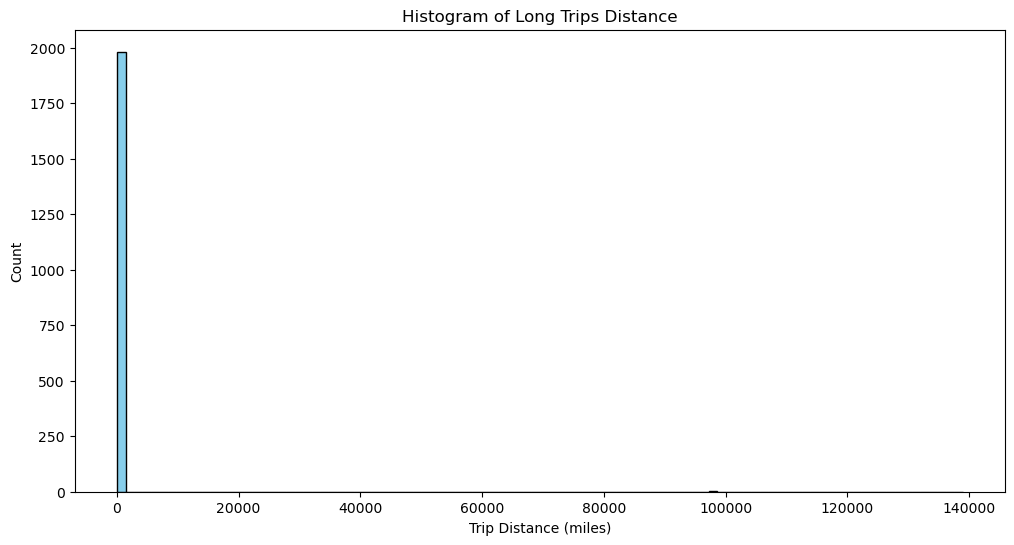

In [38]:
# Plotting the dataframe of long distance trips, we can notice that the data have outliers

plt.figure(figsize=(12,6))
plt.hist(long_dist['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Long Trips Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

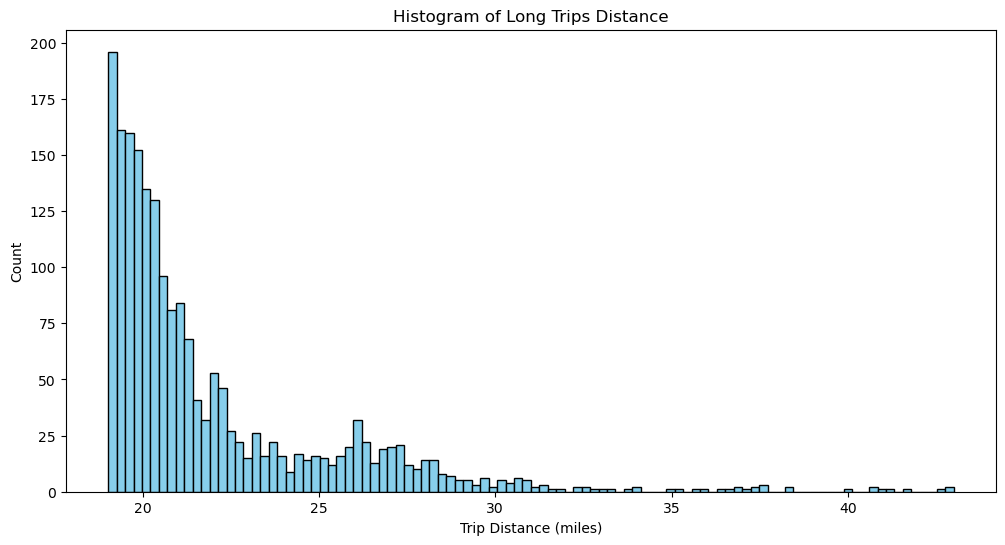

In [39]:
# Filtering the data and now its possible to check the outliers or the range in what the data looks normal distributed

ld_filtered = long_dist[long_dist['Trip_Distance'] < 44]
plt.figure(figsize=(12,6))
plt.hist(ld_filtered['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Long Trips Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

In [40]:
# For the outliers i decide to drop all the records that have more than 35 miles in the trip distance
# because they represent extreme outliers, as observed in the distribution plot and supported by percentile analysis

df1 = df1.drop(index=df1[df1['Trip_Distance'] >= 35].index)


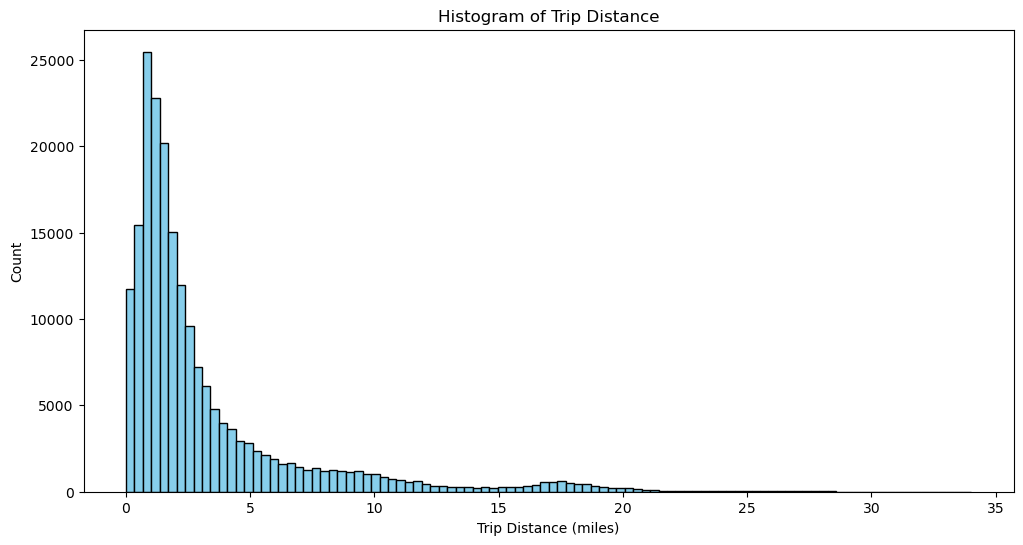

In [41]:
# Plotting again the trip distance values of the original dataset
plt.figure(figsize=(12,6))
plt.hist(df1['Trip_Distance'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

In [42]:
# Checking the info after removing outliers, aprox 40 records were removed 
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198704 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        198704 non-null  float64
 1   Trip_Distance          198704 non-null  float64
 2   Payment_Type           198704 non-null  object 
 3   Fare_Amount            198704 non-null  float64
 4   Extra                  198704 non-null  float64
 5   Mta_Tax                198704 non-null  float64
 6   Tip_Amount             198704 non-null  float64
 7   Tolls_Amount           198704 non-null  float64
 8   Improvement_Surcharge  198704 non-null  float64
 9   Total_Amount           198704 non-null  float64
 10  Congestion_Surcharge   198704 non-null  float64
 11  Airport_Fee            198704 non-null  float64
 12  Cbd_Congestion_Fee     198704 non-null  float64
 13  Trip_Duration          198704 non-null  float64
 14  Vendor                 198704 non-null  o

In [43]:
# tip_amount > 50

big_tips = df1[df1['Tip_Amount'] > 50].sample(3, random_state=42)
big_tips

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
4761,1.0,0.0,Credit card,23.0,0.0,0.0,88.0,0.0,1.0,112.75,0.0,0.0,0.75,0.066667,Curb,Newark,N,Yellow Zone,Yellow Zone
19659,3.0,0.0,Credit card,450.0,0.0,0.5,90.3,0.0,1.0,541.80,0.0,0.0,0.00,0.000000,Helix,Negotiated,N,Boro Zone,Boro Zone
84995,4.0,0.0,Credit card,300.0,0.0,0.0,60.2,0.0,1.0,361.20,0.0,0.0,0.00,0.166667,Curb,Negotiated,N,Boro Zone,Boro Zone


In [44]:
# negative fares o negative total amount

negative_fares = df1[df1['Total_Amount'] < 0]
negative_fares.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
72,1.0,0.85,Dispute,-6.5,-2.5,-0.5,0.0,0.0,-1.0,-13.00,-2.5,0.0,0.00,3.616667,Curb,Standard rate,N,Yellow Zone,Yellow Zone
268,1.0,0.42,Cash,-5.1,0.0,-0.5,0.0,0.0,-1.0,-9.10,-2.5,0.0,0.00,3.266667,Curb,Standard rate,N,Yellow Zone,Yellow Zone
578,1.0,1.33,Dispute,-9.3,0.0,-0.5,0.0,0.0,-1.0,-14.05,-2.5,0.0,-0.75,7.116667,Curb,Standard rate,N,Yellow Zone,Yellow Zone
582,1.0,4.19,Dispute,-24.7,-2.5,-0.5,0.0,0.0,-1.0,-31.20,-2.5,0.0,0.00,26.050000,Curb,Standard rate,N,Yellow Zone,Boro Zone
856,1.0,0.42,Dispute,-8.6,0.0,-0.5,0.0,0.0,-1.0,-13.35,-2.5,0.0,-0.75,8.750000,Curb,Standard rate,N,Yellow Zone,Yellow Zone


In [45]:
# Passenger_Count > 4 , normal yellow taxi should have no more than 4 passangers usually  
# but in this case is possible to have 4 or 6 as max amount of passengers
many_passengers = df1[df1['Passenger_Count'] > 4]
many_passengers.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone
711,5.0,4.25,Credit card,20.5,1.0,0.5,5.25,0.0,1.0,31.50,2.5,0.00,0.75,15.566667,Curb,Standard rate,N,Yellow Zone,Boro Zone
1279,5.0,2.58,Credit card,22.6,0.0,0.5,5.47,0.0,1.0,32.82,2.5,0.00,0.75,26.333333,Curb,Standard rate,N,Yellow Zone,Yellow Zone
1328,5.0,1.62,Credit card,10.7,2.5,0.5,3.59,0.0,1.0,21.54,2.5,0.00,0.75,7.733333,Curb,Standard rate,N,Yellow Zone,Yellow Zone
1633,5.0,1.38,Credit card,8.6,1.0,0.5,2.72,0.0,1.0,16.32,2.5,0.00,0.00,5.100000,Curb,Standard rate,N,Yellow Zone,Yellow Zone
1705,6.0,17.52,Credit card,70.0,5.0,0.5,16.30,0.0,1.0,97.80,2.5,1.75,0.75,62.633333,Curb,JFK,N,Airports,Yellow Zone


In [46]:
# I decide to create a new column with the base fare amount, using the tip amount feature because this is optional and depends on the passenger
# and we can use this new Base_Fare to experiment

df1['Base_Fare'] = df1['Total_Amount'] - df1['Tip_Amount']

In [47]:
# Because values like Fare_amount, Extra, Base_Fare or Total_Amount shoul not be negative, i will drop all the records with negatives fares

# First i save the index of these records
neg_indices = df1[(df1['Fare_Amount'] < 0) | (df1['Extra'] < 0) | (df1['Base_Fare'] < 0) | (df1['Total_Amount'] < 0)].index

# then i drop those records
df1 = df1.drop(index=neg_indices)

In [48]:
# summary statistics shows that the are no more negative values
df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000,197099.000000
mean,1.159372,3.244432,21.721291,1.031042,0.495117,2.632296,0.475934,0.968779,30.251015,1.556363,0.100418,0.531803,17.686030,27.618719
std,0.540535,3.962797,16.611683,1.685919,0.049171,3.644527,1.982831,0.172907,19.799295,1.211878,0.425883,0.340644,21.585950,18.085256
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.500000,0.000000,0.000000,0.000000,9.660000,0.000000,0.000000,0.000000,0.000000,8.750000
25%,1.000000,1.000000,10.700000,0.000000,0.500000,0.000000,0.000000,1.000000,17.700000,0.000000,0.000000,0.000000,8.466667,15.750000
50%,1.000000,1.800000,16.300000,0.000000,0.500000,2.000000,0.000000,1.000000,24.060000,2.500000,0.000000,0.750000,14.033333,21.750000
75%,1.000000,3.640000,27.500000,1.750000,0.500000,3.850000,0.000000,1.000000,35.410000,2.500000,0.000000,0.750000,22.133333,33.130000
99%,4.000000,18.960000,75.100000,6.000000,0.500000,16.800000,7.460000,1.000000,102.210200,2.500000,1.750000,0.750000,71.583333,88.750000
max,6.000000,34.020000,650.000000,12.500000,0.500000,99.990000,106.430000,1.000000,651.000000,2.500000,26.750000,0.750000,1438.316667,651.000000


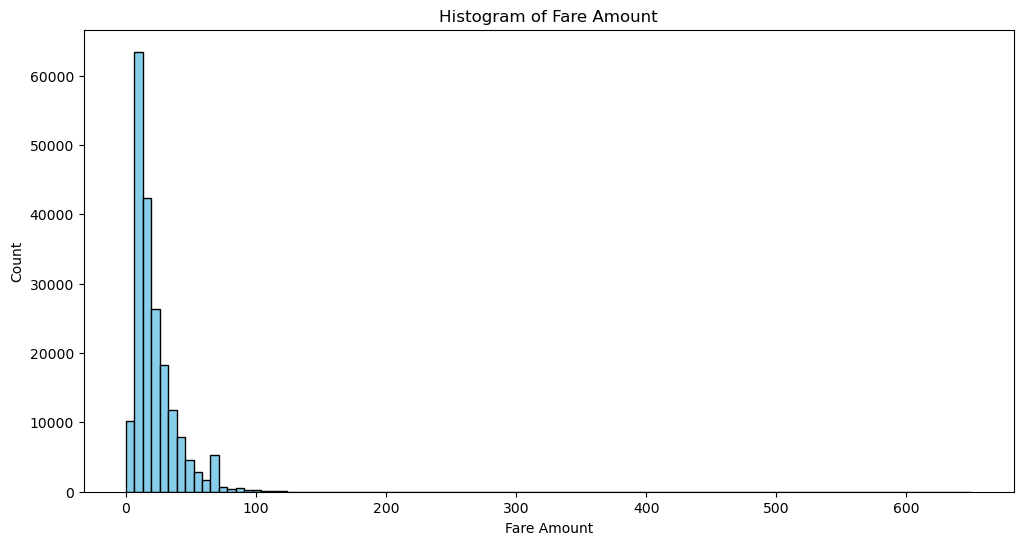

In [49]:
# Plot of Fare Amount to check outliers
plt.figure(figsize=(12,6))
plt.hist(df1['Fare_Amount'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Count')
plt.show()

In [50]:
# index of records where Fare_Amount is above the 99% percentile
outlier_indices = df1[df1['Fare_Amount'] > df1['Fare_Amount'].quantile(0.99)].index

# then drop those records
df1 = df1.drop(index=outlier_indices)

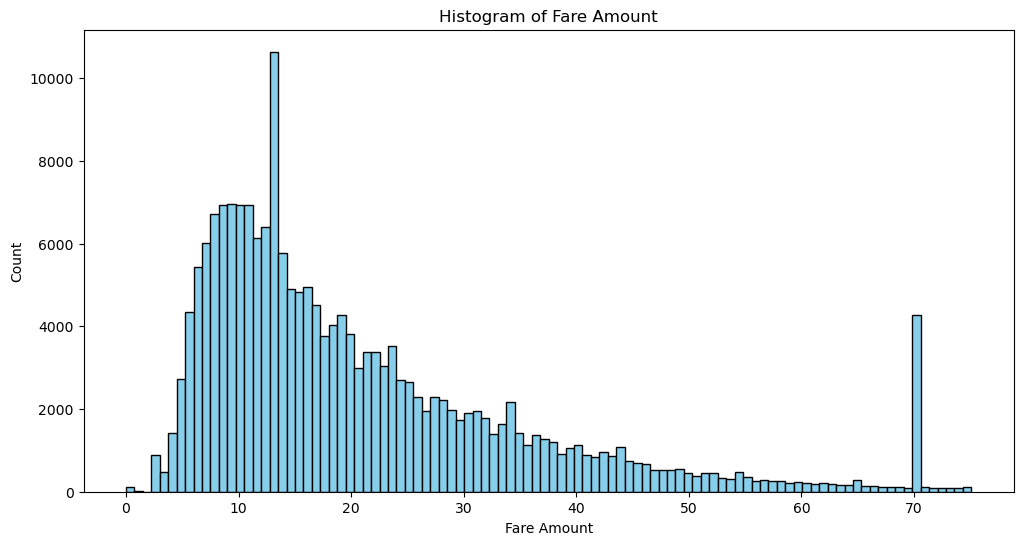

In [51]:
# Plott of Fare Amount to check the distribution after removing outliers
plt.figure(figsize=(12,6))
plt.hist(df1['Fare_Amount'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Count')
plt.show()

In [52]:
# Checking the info after removing outliers, aprox 4k records were removed 
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195133 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        195133 non-null  float64
 1   Trip_Distance          195133 non-null  float64
 2   Payment_Type           195133 non-null  object 
 3   Fare_Amount            195133 non-null  float64
 4   Extra                  195133 non-null  float64
 5   Mta_Tax                195133 non-null  float64
 6   Tip_Amount             195133 non-null  float64
 7   Tolls_Amount           195133 non-null  float64
 8   Improvement_Surcharge  195133 non-null  float64
 9   Total_Amount           195133 non-null  float64
 10  Congestion_Surcharge   195133 non-null  float64
 11  Airport_Fee            195133 non-null  float64
 12  Cbd_Congestion_Fee     195133 non-null  float64
 13  Trip_Duration          195133 non-null  float64
 14  Vendor                 195133 non-null  o

In [53]:
df1.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000
mean,1.157221,3.142652,21.006492,1.035258,0.497292,2.563341,0.432084,0.968572,29.435572,1.567713,0.095573,0.533559,17.461166,26.872231
std,0.536215,3.746562,14.830464,1.688083,0.036700,3.449415,1.799589,0.173457,17.870069,1.208952,0.417141,0.339830,21.382891,16.319832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.500000,0.000000,0.000000,0.000000,9.600000,0.000000,0.000000,0.000000,0.000000,8.750000
25%,1.000000,1.000000,10.220000,0.000000,0.500000,0.000000,0.000000,1.000000,17.700000,0.000000,0.000000,0.000000,8.450000,15.750000
50%,1.000000,1.780000,16.300000,0.000000,0.500000,2.000000,0.000000,1.000000,23.960000,2.500000,0.000000,0.750000,13.966667,21.700000
75%,1.000000,3.580000,27.190000,2.500000,0.500000,3.790000,0.000000,1.000000,34.950000,2.500000,0.000000,0.750000,21.883333,32.670000
99%,4.000000,18.420000,70.000000,6.000000,0.500000,16.440000,7.460000,1.000000,98.660000,2.500000,1.750000,0.750000,69.700000,83.960000
max,6.000000,34.020000,75.100000,12.500000,0.500000,99.990000,106.430000,1.000000,182.930000,2.500000,26.750000,0.750000,1438.316667,182.930000


# Saving the Dataset cleaned and checking again the content

In [54]:
# Saving the dataset cleaned 

df1.to_csv("Dataset/taxi_data_cleaned_test.csv", index=False)

In [55]:
# Reading the new dataset cleaned

df_cleaned = pd.read_csv('Dataset/taxi_data_cleaned_test.csv')
df_cleaned.head()

,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Vendor,Rate_Type,Stored_Flag,PU_zone,DO_zone,Base_Fare
0,1.0,17.47,Credit card,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75,32.600000,Curb,Standard rate,N,Yellow Zone,Airports,82.51
1,1.0,2.14,Flex Fare,16.96,0.0,0.5,0.00,0.00,1.0,22.96,0.0,0.0,0.00,11.000000,Curb,Standard rate,N,Yellow Zone,Yellow Zone,22.96
2,1.0,1.27,Credit card,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75,6.916667,Curb,Standard rate,N,Yellow Zone,Yellow Zone,14.05
3,2.0,1.41,Credit card,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00,9.950000,Curb,Standard rate,N,Yellow Zone,Yellow Zone,14.70
4,2.0,2.73,Credit card,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75,18.150000,Curb,Standard rate,N,Yellow Zone,Yellow Zone,23.45


# Feature Engineering

## Exploratory Data Analysis

In [56]:
# creating a copy of the cleaned dataframe
df = df_cleaned.copy()

In [57]:
# checking the info and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195133 entries, 0 to 195132
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Passenger_Count        195133 non-null  float64
 1   Trip_Distance          195133 non-null  float64
 2   Payment_Type           195133 non-null  object 
 3   Fare_Amount            195133 non-null  float64
 4   Extra                  195133 non-null  float64
 5   Mta_Tax                195133 non-null  float64
 6   Tip_Amount             195133 non-null  float64
 7   Tolls_Amount           195133 non-null  float64
 8   Improvement_Surcharge  195133 non-null  float64
 9   Total_Amount           195133 non-null  float64
 10  Congestion_Surcharge   195133 non-null  float64
 11  Airport_Fee            195133 non-null  float64
 12  Cbd_Congestion_Fee     195133 non-null  float64
 13  Trip_Duration          195133 non-null  float64
 14  Vendor                 195133 non-nu

In [58]:
df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
count,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000,195133.000000
mean,1.157221,3.142652,21.006492,1.035258,0.497292,2.563341,0.432084,0.968572,29.435572,1.567713,0.095573,0.533559,17.461166,26.872231
std,0.536215,3.746562,14.830464,1.688083,0.036700,3.449415,1.799589,0.173457,17.870069,1.208952,0.417141,0.339830,21.382891,16.319832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.000000,0.000000,4.400000,0.000000,0.500000,0.000000,0.000000,0.000000,9.600000,0.000000,0.000000,0.000000,0.000000,8.750000
25%,1.000000,1.000000,10.220000,0.000000,0.500000,0.000000,0.000000,1.000000,17.700000,0.000000,0.000000,0.000000,8.450000,15.750000
50%,1.000000,1.780000,16.300000,0.000000,0.500000,2.000000,0.000000,1.000000,23.960000,2.500000,0.000000,0.750000,13.966667,21.700000
75%,1.000000,3.580000,27.190000,2.500000,0.500000,3.790000,0.000000,1.000000,34.950000,2.500000,0.000000,0.750000,21.883333,32.670000
99%,4.000000,18.420000,70.000000,6.000000,0.500000,16.440000,7.460000,1.000000,98.660000,2.500000,1.750000,0.750000,69.700000,83.960000
max,6.000000,34.020000,75.100000,12.500000,0.500000,99.990000,106.430000,1.000000,182.930000,2.500000,26.750000,0.750000,1438.316667,182.930000


In [59]:
# Correlation features with Total Amount as target

df.corr(numeric_only=True).Total_Amount.abs().sort_values(ascending=False)[1:]

Base_Fare                0.983721
Fare_Amount              0.955873
Trip_Distance            0.820762
Tolls_Amount             0.603736
Airport_Fee              0.541166
Tip_Amount               0.526440
Trip_Duration            0.449810
Congestion_Surcharge     0.201444
Extra                    0.151378
Mta_Tax                  0.112559
Improvement_Surcharge    0.062351
Cbd_Congestion_Fee       0.043401
Passenger_Count          0.018683
Name: Total_Amount, dtype: float64

In [60]:
# Correlation features with Base Fare as target

df.corr(numeric_only=True).Base_Fare.abs().sort_values(ascending=False)[1:]

Total_Amount             0.983721
Fare_Amount              0.978596
Trip_Distance            0.813192
Tolls_Amount             0.579813
Airport_Fee              0.501041
Trip_Duration            0.457684
Tip_Amount               0.365084
Congestion_Surcharge     0.303711
Mta_Tax                  0.104540
Improvement_Surcharge    0.096730
Extra                    0.088146
Cbd_Congestion_Fee       0.031368
Passenger_Count          0.003696
Name: Base_Fare, dtype: float64

In [61]:
# create a copy of the original dataset without the categorical columns only the numerical data, and save it in a new dataframe

dfnum = df[df.select_dtypes(include=['number']).columns]

dfnum.reset_index(drop=True, inplace=True)
dfnum.head()

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,Airport_Fee,Cbd_Congestion_Fee,Trip_Duration,Base_Fare
0,1.0,17.47,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,0.0,0.75,32.600000,82.51
1,1.0,2.14,16.96,0.0,0.5,0.00,0.00,1.0,22.96,0.0,0.0,0.00,11.000000,22.96
2,1.0,1.27,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,0.0,0.75,6.916667,14.05
3,2.0,1.41,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,0.0,0.00,9.950000,14.70
4,2.0,2.73,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,0.0,0.75,18.150000,23.45


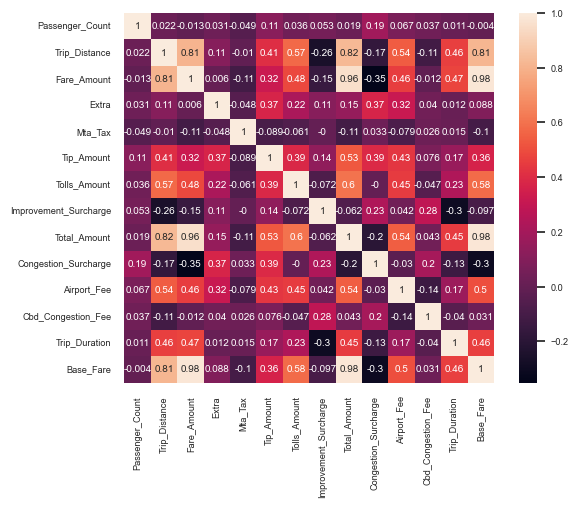

In [62]:
# Now we can map the heatmap of the correlation

cm = np.corrcoef(dfnum.values.T).round(3)

sns.set(font_scale=0.6)
sns.heatmap(cm,
            square=True,
            annot=True,
            yticklabels=dfnum.columns,
            xticklabels=dfnum.columns)
plt.show()

- By looking in the heat map and having as target the **Total_Amount** column, is possible to see the correlation and confirm that Fare_Amount, Trip_Distance, Tips_Amount, Tolls_Amount, Airport_Fee and Trip_Duration have a appropiate correlation value.
- Also Base_Fare looks to have a high correlation but this features is basically the Total_amount with out the tips from the passenger, so maybe i can change to predict this feature, but i think depending the location of the trips the tips have some influence or its more possible to get a tip.              

## Creating dummy values for categorical data
- In this step create dummies for all the categorical features and save it in a new dataframe, i can use this to make some experiments

In [63]:
# Checking the categories for the categorical columns

# Payment type value count
df.Payment_Type.value_counts()

Payment_Type
Credit card    118898
Flex Fare       59115
Cash            15423
Dispute          1169
No charge         528
Name: count, dtype: int64

In [64]:
# Vendor value count

df.Vendor.value_counts()

Vendor
Curb        155328
Creative     37067
Helix         2408
Myle           330
Name: count, dtype: int64

In [65]:
# Rate_Type value count

df.Rate_Type.value_counts()

Rate_Type
Standard rate    189976
JFK                4101
Negotiated          776
Newark              262
Nassau               18
Name: count, dtype: int64

In [66]:
# Stored_Flag value count

df.Stored_Flag.value_counts()

Stored_Flag
N    195036
Y        97
Name: count, dtype: int64

In [67]:
# PU_zone and DO_zone value count 

print(df.DO_zone.value_counts())
df.PU_zone.value_counts()

DO_zone
Yellow Zone    158921
Boro Zone       33617
Airports         2566
EWR                29
Name: count, dtype: int64


PU_zone
Yellow Zone    161385
Boro Zone       23393
Airports        10350
EWR                 5
Name: count, dtype: int64

In [68]:
# creating the dummies for the categorical columns from the dataframe

df_dummys = pd.get_dummies(df, drop_first=True, dtype=int)
df_dummys.reset_index(inplace=True, drop=True)
print(df_dummys.info())
df_dummys.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195133 entries, 0 to 195132
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Passenger_Count           195133 non-null  float64
 1   Trip_Distance             195133 non-null  float64
 2   Fare_Amount               195133 non-null  float64
 3   Extra                     195133 non-null  float64
 4   Mta_Tax                   195133 non-null  float64
 5   Tip_Amount                195133 non-null  float64
 6   Tolls_Amount              195133 non-null  float64
 7   Improvement_Surcharge     195133 non-null  float64
 8   Total_Amount              195133 non-null  float64
 9   Congestion_Surcharge      195133 non-null  float64
 10  Airport_Fee               195133 non-null  float64
 11  Cbd_Congestion_Fee        195133 non-null  float64
 12  Trip_Duration             195133 non-null  float64
 13  Base_Fare                 195133 non-null  f

,Passenger_Count,Trip_Distance,Fare_Amount,Extra,Mta_Tax,Tip_Amount,Tolls_Amount,Improvement_Surcharge,Total_Amount,Congestion_Surcharge,...,Rate_Type_Negotiated,Rate_Type_Newark,Rate_Type_Standard rate,Stored_Flag_Y,PU_zone_Boro Zone,PU_zone_EWR,PU_zone_Yellow Zone,DO_zone_Boro Zone,DO_zone_EWR,DO_zone_Yellow Zone
0,1.0,17.47,65.30,5.0,0.5,16.50,7.46,1.0,99.01,2.5,...,0,0,1,0,0,0,1,0,0,0
1,1.0,2.14,16.96,0.0,0.5,0.00,0.00,1.0,22.96,0.0,...,0,0,1,0,0,0,1,0,0,1
2,1.0,1.27,9.30,0.0,0.5,2.81,0.00,1.0,16.86,2.5,...,0,0,1,0,0,0,1,0,0,1
3,2.0,1.41,10.70,0.0,0.5,2.94,0.00,1.0,17.64,2.5,...,0,0,1,0,0,0,1,0,0,1
4,2.0,2.73,17.70,1.0,0.5,4.69,0.00,1.0,28.14,2.5,...,0,0,1,0,0,0,1,0,0,1


In [69]:
df_dummys.corr().Total_Amount.abs().sort_values(ascending=False)[1:]

Base_Fare                   0.983721
Fare_Amount                 0.955873
Trip_Distance               0.820762
Tolls_Amount                0.603736
Airport_Fee                 0.541166
Rate_Type_Standard rate     0.534276
Tip_Amount                  0.526440
Trip_Duration               0.449810
PU_zone_Yellow Zone         0.412059
DO_zone_Yellow Zone         0.267046
Congestion_Surcharge        0.201444
DO_zone_Boro Zone           0.190805
Extra                       0.151378
Payment_Type_Flex Fare      0.126939
Mta_Tax                     0.112559
Rate_Type_Negotiated        0.093428
PU_zone_Boro Zone           0.093161
Rate_Type_Newark            0.076189
Improvement_Surcharge       0.062351
Payment_Type_Credit card    0.060491
Cbd_Congestion_Fee          0.043401
DO_zone_EWR                 0.040651
Vendor_Curb                 0.039690
Payment_Type_No charge      0.027259
Vendor_Helix                0.025172
Passenger_Count             0.018683
Payment_Type_Dispute        0.018390
R

### Saving the dataset with dummies to make the prediction with the model

- the dataframe would be saved and exported asc .csv file, this will allow me use the total new data to predict using the model selected

In [82]:
## Saving the X1_test , to use it in the principal document to predict 
df_dummys.to_csv("Dataset/df_dummys_test.csv", index=False)